# Create 100 foot defensible space buffer geometry around buildings

In [16]:
import os
import sys

import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.patches import Patch

sys.path.append("../utils")

import config

### Import inspection geometries and parcel boundaries

In [17]:
# Import joined inspections and buildings
def import_inspections_buildings_data(year):
    """
    Function to read in inspections data for a given year and convert to Albers CRS.
    """
    inspections_with_buildings = os.path.join(
        config.data_dir,
        "joined_inspections_buildings",
        f"inspections_with_buildings_{year}.geojson",
    )
    inspections_with_buildings = gpd.read_file(inspections_with_buildings).to_crs(
        config.albers_crs
    )
    return inspections_with_buildings


# Read in joined inspections and buildings data for 2019-2023 as separate dataframes
inspections_with_buildings_dict = {}
for year in range(2019, 2024):
    inspections_with_buildings_dict[year] = import_inspections_buildings_data(year)

In [18]:
# Unpack inspections with buildings from dictionary
inspections_with_buildings_2019 = inspections_with_buildings_dict[2019]
inspections_with_buildings_2020 = inspections_with_buildings_dict[2020]
inspections_with_buildings_2021 = inspections_with_buildings_dict[2021]
inspections_with_buildings_2022 = inspections_with_buildings_dict[2022]
inspections_with_buildings_2023 = inspections_with_buildings_dict[2023]

In [19]:
# Read in complete parcels data and convert to Albers CRS
parcels = os.path.join(config.data_dir, "parcel_boundaries", "cbiinputs.gdb")
parcels = gpd.read_file(parcels).to_crs(config.albers_crs)

In [20]:
# Import SB county boundary
sb_county = gpd.read_file(
    os.path.join(config.data_dir, "ca_counties", "sb_county_boundary.shp")
).to_crs(config.albers_crs)

## Buffer building polygons

To make sure buffer areas are accurate, transform data to an equal area projection. We will use California Teale-Albers (EPSG: 3310). 

Create a 100 foot buffer around all of the building polygons. 100 feet = ~30.48 meters.

### Test for single year (2019)

In [21]:
# Drop columns before merging
inspections_with_buildings_2019 = inspections_with_buildings_2019.drop(columns=["apn"])

In [22]:
# Create a copy of parcels with just APN and geometry
parcels_apn = parcels[["apn", "geometry"]].copy()

# Join parcels to inspections
inspections_with_buildings_2019 = gpd.sjoin(
    inspections_with_buildings_2019,
    parcels_apn,
    how="left",
    predicate="intersects",
)

# Drop the index_right column
inspections_with_buildings_2019 = inspections_with_buildings_2019.drop(
    columns=["index_right"]
)

In [23]:
# Create a buffer for the inspection and building geometries
buffered_2019 = inspections_with_buildings_2019.copy()
buffered_2019["geometry"] = buffered_2019.geometry.buffer(
    30.48, resolution=50, cap_style=3, join_style=2
).envelope

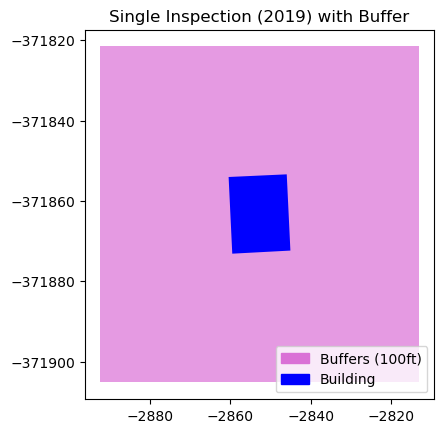

In [24]:
# Verify buffer creation by plotting
fig, ax = plt.subplots()

# Create patches for the legend
buffer_patch = Patch(color="orchid", label="Buffers (100ft)")
building_patch = Patch(color="blue", label="Buildings")

# Plot the buffered buildings
buffered_2019.geometry.head(1).plot(
    ax=ax, color="orchid", alpha=0.7, label="Buffers (100ft)"
)

# Plot the buildings
inspections_with_buildings_2019.head(1).plot(ax=ax, color="blue", label="Building")

# Add labels and legend
plt.title("Single Inspection (2019) with Buffer")
ax.legend(
    [buffer_patch, building_patch],
    ["Buffers (100ft)", "Building"],
    loc="lower right",
)
plt.show()

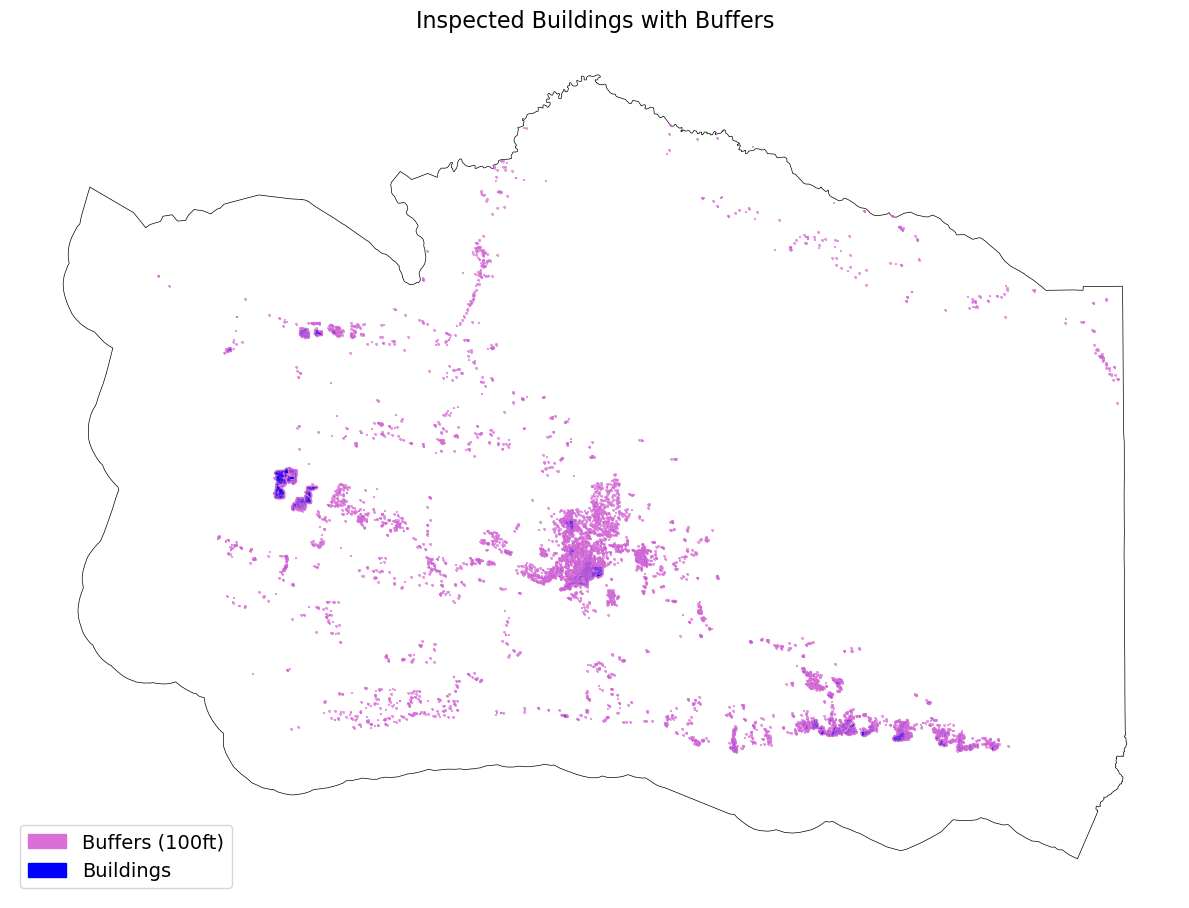

In [25]:
# Plot all buffers and buildings on the map
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the Santa Barbara county boundary
sb_county.boundary.plot(ax=ax, color="black", linewidth=0.5)

# Plot the buffers
buffered_2019.boundary.plot(ax=ax, alpha=0.7, color="orchid")

# Plot the buildings
inspections_with_buildings_2019.boundary.plot(
    ax=ax, color="blue", linewidth=0.1, alpha=0.5
)

# Add labels and legend
plt.title("Inspected Buildings with Buffers", size=16)
buffer_patch = Patch(color="orchid", label="Buffers (100ft)")
building_patch = Patch(color="blue", label="Buildings")
ax.legend(handles=[buffer_patch, building_patch], loc="lower left", prop={"size": 14})
ax.axis("off")
plt.tight_layout()
plt.show()

In [26]:
# Convert data to Web Mercator for basemap overlay
sb_county_mercator = sb_county.to_crs(config.mercator_crs)
buffered_2019_mercator = buffered_2019.to_crs(config.mercator_crs)
buildings_mercator = inspections_with_buildings_2019.to_crs(config.mercator_crs)

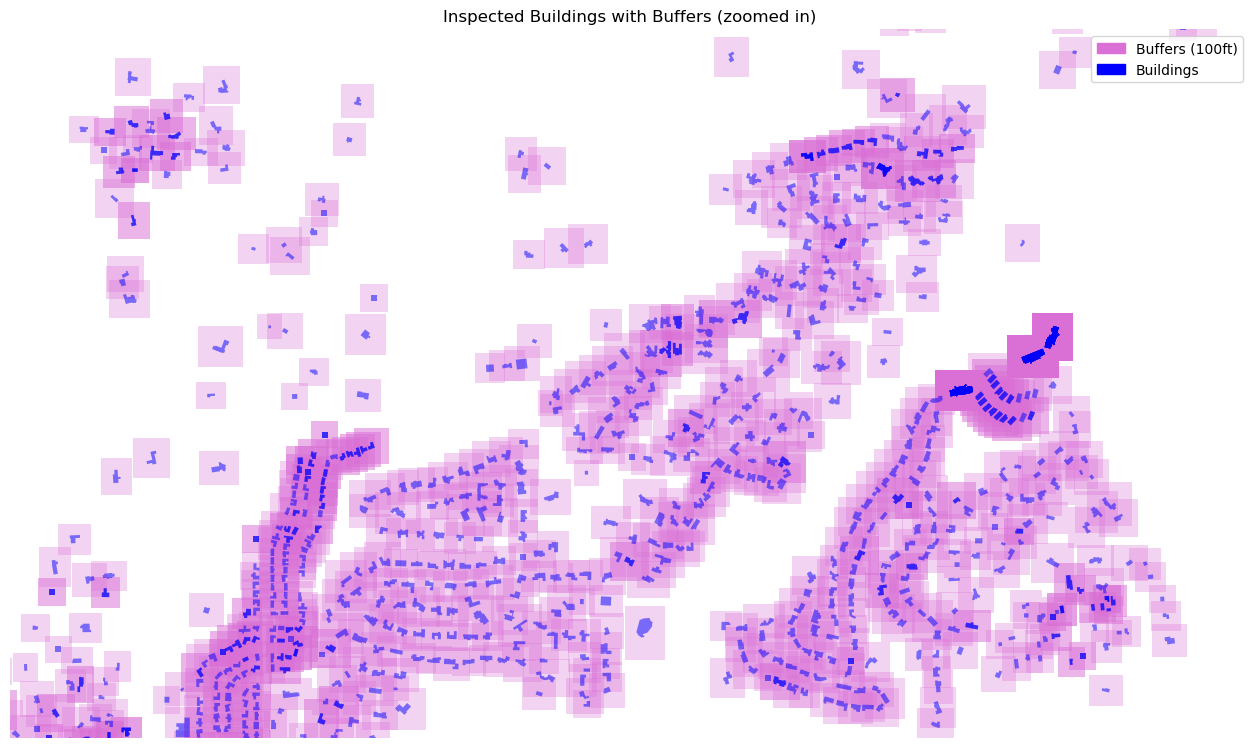

In [27]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(16, 12))

# Plot the buffers
buffered_2019.plot(ax=ax, alpha=0.3, color="orchid")

# Plot the buildings
inspections_with_buildings_2019.plot(ax=ax, color="blue", linewidth=0.1, alpha=0.5)

# Set axis limits to zoom in
ax.set_xlim(18000, 21500)
ax.set_ylim(-396000, -394000)

# Add labels and legend
plt.title("Inspected Buildings with Buffers (zoomed in)")
buffer_patch = Patch(color="orchid", label="Buffers (100ft)")
building_patch = Patch(color="blue", label="Buildings")
ax.legend(handles=[buffer_patch, building_patch], loc="upper right")
ax.axis("off")
plt.show()

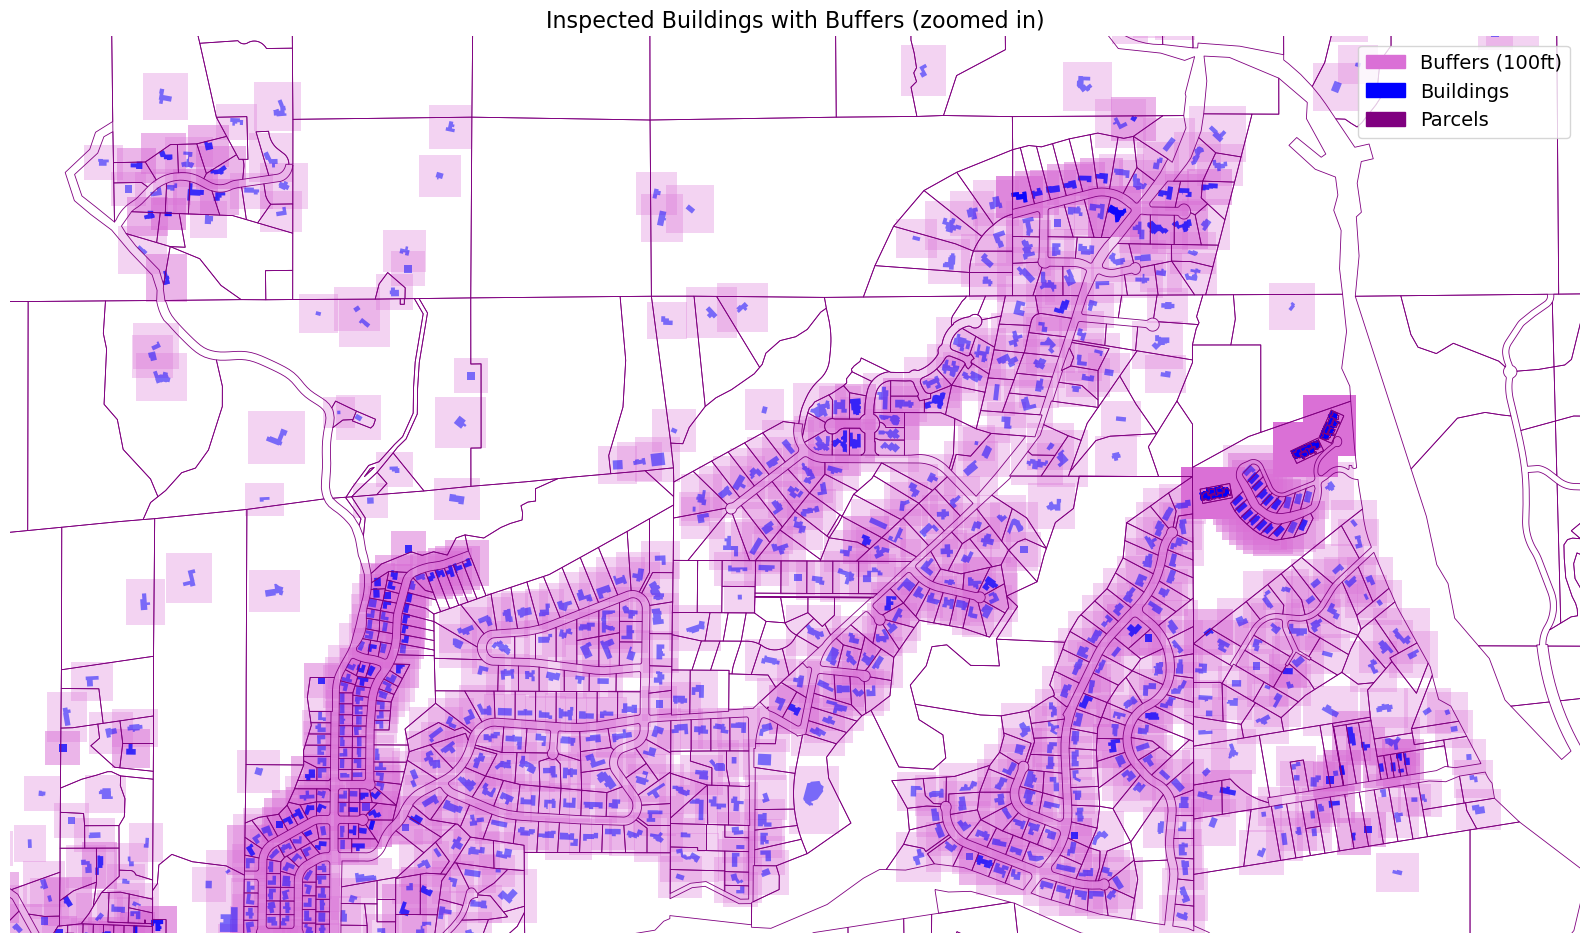

In [28]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(16, 12))

# Plot the buffers
buffered_2019.plot(ax=ax, alpha=0.3, color="orchid")

# Plot the buildings
inspections_with_buildings_2019.plot(ax=ax, color="blue", linewidth=0.1, alpha=0.5)

# Plot the parcel boundaries
parcels.boundary.plot(ax=ax, color="purple", linewidth=0.6)

# Set axis limits to zoom in
ax.set_xlim(18000, 21500)
ax.set_ylim(-396000, -394000)

# Add labels and legend
plt.title("Inspected Buildings with Buffers (zoomed in)", size=16)
buffer_patch = Patch(color="orchid", label="Buffers (100ft)")
building_patch = Patch(color="blue", label="Buildings")
parcel_patch = Patch(color="purple", label="Parcels")
ax.legend(
    handles=[buffer_patch, building_patch, parcel_patch],
    loc="upper right",
    prop={"size": 14},
)
ax.axis("off")
plt.tight_layout()
plt.show()

## Save buffers to file as training geomtries

Saved in `/capstone/wildfire_prep/data/training_geometries`

In [29]:
def buffer_buildings_unclipped(year):
    """
    Function to buffer buildings in a given year without clipping by parcels.
    """
    # Read in inspections with buildings data for the given year
    inspections = inspections_with_buildings_dict[year]

    # Add month and year columns if needed
    inspections["month"] = inspections["Date"].dt.month
    inspections["year"] = inspections["Date"].dt.year

    # Create rectangular buffers
    buffered_geometry = inspections.geometry.buffer(
        30.48, resolution=50, cap_style=3, join_style=2
    ).envelope

    # Create a new GeoDataFrame
    columns_to_keep = ["inspection_id", "apn", "Date", "year", "month", "status"]

    buffered = gpd.GeoDataFrame(
        inspections[columns_to_keep], geometry=buffered_geometry, crs=inspections.crs
    )

    return buffered


# Process all years
buffered_geometries_dict = {}
for year in range(2019, 2024):
    buffered_geometries_dict[year] = buffer_buildings_unclipped(year)

# Save the processed datasets
for year, data in buffered_geometries_dict.items():
    output_path = os.path.join(
        config.data_dir,
        "training_geometries",
        f"training_geometries_{year}.geojson",
    )
    data.to_file(output_path, driver="GeoJSON")

#### Check if there are the correct number of geometries

In [30]:
# Check the number of geometries in each year's dataset
for year, data in buffered_geometries_dict.items():
    print(f"Year {year}: {len(data)} geometries")

    # Check for any missing values in key columns
    if "status" in data.columns:
        compliant_count = data[data["status"] == "Compliant"].shape[0]
        non_compliant_count = data[data["status"] == "Non-Compliant"].shape[0]
        print(f"  - Compliant: {compliant_count}")
        print(f"  - Non-Compliant: {non_compliant_count}")

    # Check for any null geometries
    null_geoms = data[data.geometry.is_empty | data.geometry.isna()].shape[0]
    if null_geoms > 0:
        print(f"  - Warning: {null_geoms} null or empty geometries")

    print()  # Add a blank line between years

Year 2019: 14675 geometries
  - Compliant: 14552
  - Non-Compliant: 123

Year 2020: 11878 geometries
  - Compliant: 11784
  - Non-Compliant: 94

Year 2021: 14012 geometries
  - Compliant: 13942
  - Non-Compliant: 70

Year 2022: 13642 geometries
  - Compliant: 13582
  - Non-Compliant: 60

Year 2023: 13373 geometries
  - Compliant: 13302
  - Non-Compliant: 71



## Clip building buffers to parcels

The 100 foot buffers for buildings tend to overlap, meaning we need to clip to each parcel since compliance status is determined based on property ownership. 

Saved in `/capstone/wildfire_prep/data/buffer_geometries`

In [31]:
def buffer_buildings(year):
    """
    Buffer buildings in a given year, ensuring one output geometry per inspection,
    with each inspection associated with the parcel containing its largest area.
    """
    # Read in inspections with buildings data for the given year
    inspections_with_buildings = inspections_with_buildings_dict[year].copy()

    # Drop columns that might conflict with the spatial join
    columns_to_drop = [
        col
        for col in inspections_with_buildings.columns
        if col in ["index_right", "index_left"]
    ]
    if columns_to_drop:
        inspections_with_buildings = inspections_with_buildings.drop(
            columns=columns_to_drop
        )

    if "apn" in inspections_with_buildings.columns:
        inspections_with_buildings = inspections_with_buildings.drop(columns=["apn"])

    # Store the original count for validation
    original_count = len(inspections_with_buildings)
    print(f"Year {year}: Original inspection count = {original_count}")

    # Ensure we have a unique identifier for each inspection
    if "inspection_id" not in inspections_with_buildings.columns:
        inspections_with_buildings.loc[:, "inspection_id"] = (
            inspections_with_buildings.index
        )

    # STEP 1: Spatial join to find all parcels intersecting with each inspection
    intersections = gpd.sjoin(
        inspections_with_buildings, parcels_apn, how="left", predicate="intersects"
    )

    # If no intersections found for some inspections, keep those records separate
    no_intersection_mask = intersections["index_right"].isna()
    no_intersection = inspections_with_buildings[
        ~inspections_with_buildings["inspection_id"].isin(
            intersections[~no_intersection_mask]["inspection_id"].unique()
        )
    ].copy()

    # For inspections with intersections, proceed with the analysis
    has_intersections = intersections[~no_intersection_mask].copy()

    # STEP 2: Calculate intersection areas between inspections and parcels
    # Create temporary columns to hold inspection and parcel geometries
    has_intersections.loc[:, "inspection_geom"] = has_intersections.geometry

    # Create a dictionary mapping APNs to geometries
    apn_to_geom = dict(zip(parcels_apn["apn"], parcels_apn.geometry))
    has_intersections.loc[:, "parcel_geom"] = has_intersections["apn"].map(apn_to_geom)

    # Calculate intersection areas using a vectorized operation
    has_intersections.loc[:, "intersection_area"] = has_intersections.apply(
        lambda row: row.inspection_geom.intersection(row.parcel_geom).area
        if not pd.isna(row.parcel_geom)
        else 0,
        axis=1,
    )

    # STEP 3: Find the parcel with the largest intersection area for each inspection
    has_intersections = has_intersections.sort_values(
        ["inspection_id", "intersection_area"], ascending=[True, False]
    )

    # Keep only the first row for each inspection_id (the one with the largest area)
    best_parcels = has_intersections.drop_duplicates("inspection_id").copy()

    # STEP 4: Buffer the inspection geometries
    best_parcels.loc[:, "buffered_geom"] = best_parcels.geometry.buffer(
        30.48, resolution=50, cap_style=3, join_style=2
    ).envelope

    # STEP 5: Clip the buffered geometries with their corresponding parcel
    best_parcels.loc[:, "geometry"] = best_parcels.apply(
        lambda row: row.buffered_geom.intersection(row.parcel_geom)
        if not pd.isna(row.parcel_geom)
        else row.buffered_geom,
        axis=1,
    )

    # For inspections with no intersecting parcels, buffer them but don't clip
    if len(no_intersection) > 0:
        no_intersection.loc[:, "geometry"] = no_intersection.geometry.buffer(
            30.48, resolution=50, cap_style=3, join_style=2
        ).envelope

    # STEP 6: Combine the results
    # Clean up the best_parcels DataFrame by removing temporary columns
    columns_to_keep = [
        col
        for col in best_parcels.columns
        if col
        not in [
            "inspection_geom",
            "parcel_geom",
            "intersection_area",
            "buffered_geom",
            "index_right",
        ]
    ]
    best_parcels = best_parcels[columns_to_keep]

    # Combine the results
    result = (
        pd.concat([best_parcels, no_intersection])
        if len(no_intersection) > 0
        else best_parcels
    )

    # Validate the final count
    final_count = len(result)
    print(f"Year {year}: Final geometry count = {final_count}")

    if final_count != original_count:
        print(
            f"WARNING: Final count doesn't match original! Difference: {final_count - original_count}"
        )

        # Find missing inspection IDs
        missing_ids = set(inspections_with_buildings["inspection_id"]) - set(
            result["inspection_id"]
        )

        if missing_ids:
            print(f"  Missing {len(missing_ids)} inspection IDs in final result.")

            # Recover missing inspections
            missing_inspections = inspections_with_buildings[
                inspections_with_buildings["inspection_id"].isin(missing_ids)
            ].copy()

            # Buffer these missing inspections
            missing_inspections.loc[:, "geometry"] = (
                missing_inspections.geometry.buffer(
                    30.48, resolution=50, cap_style=3, join_style=2
                ).envelope
            )

            # Add these back to the result
            result = pd.concat([result, missing_inspections])

            # Verify the count again
            print(
                f"  After recovery: Final count = {len(result)}, Match = {len(result) == original_count}"
            )

    return result

#### Process data for all years and check that there are the correct number of inspections

In [32]:
# Read in joined inspections and buildings data for 2019-2023 as separate dataframes
clipped_geometries_dict = {}
for year in range(2019, 2024):
    clipped_geometries_dict[year] = buffer_buildings(year)
    print("-" * 50)  # Separator between years

# Final validation across all years
print("\nFinal validation across all years:")
for year in range(2019, 2024):
    original_count = len(inspections_with_buildings_dict[year])
    final_count = len(clipped_geometries_dict[year])
    print(
        f"Year {year}: Original={original_count}, Final={final_count}, Match={original_count == final_count}"
    )

# Save the processed datasets
for year, data in clipped_geometries_dict.items():
    output_path = os.path.join(
        config.data_dir,
        "buffer_geometries",
        f"buffer_geometries_{year}.geojson",
    )
    data.to_file(output_path, driver="GeoJSON")

Year 2019: Original inspection count = 14675
Year 2019: Final geometry count = 14675
--------------------------------------------------
Year 2020: Original inspection count = 11878
Year 2020: Final geometry count = 11878
--------------------------------------------------
Year 2021: Original inspection count = 14012
Year 2021: Final geometry count = 14012
--------------------------------------------------
Year 2022: Original inspection count = 13642
Year 2022: Final geometry count = 13642
--------------------------------------------------
Year 2023: Original inspection count = 13373
Year 2023: Final geometry count = 13373
--------------------------------------------------

Final validation across all years:
Year 2019: Original=14675, Final=14675, Match=True
Year 2020: Original=11878, Final=11878, Match=True
Year 2021: Original=14012, Final=14012, Match=True
Year 2022: Original=13642, Final=13642, Match=True
Year 2023: Original=13373, Final=13373, Match=True


#### Plot 2019 buffer geometries to verify clipping

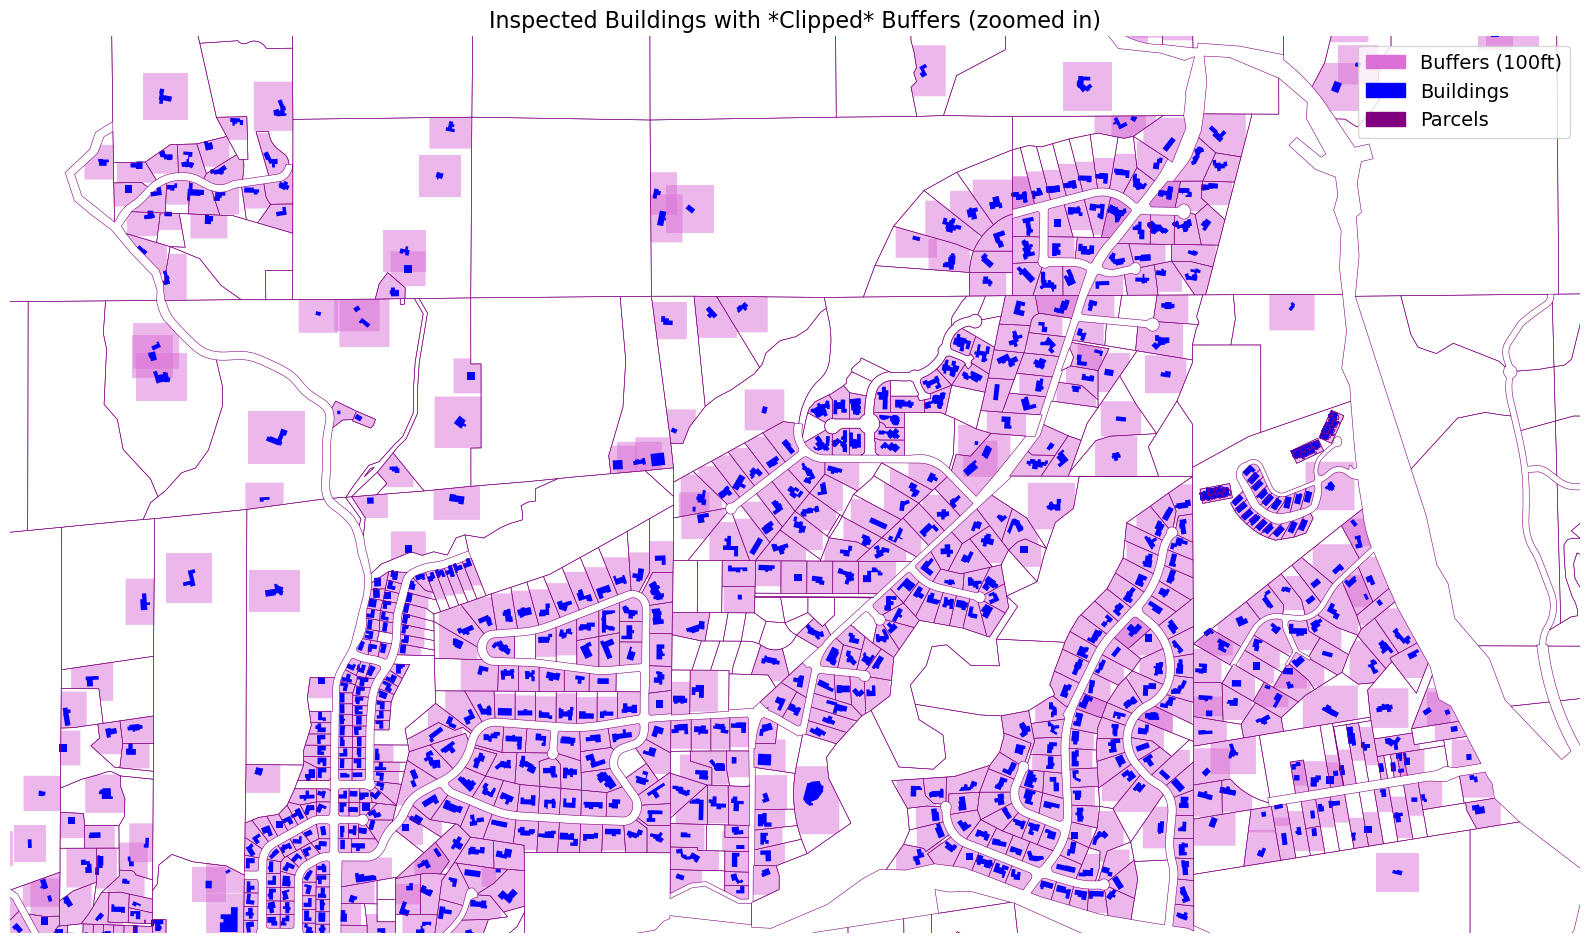

In [33]:
# Plot clipped buffers
fig, ax = plt.subplots(figsize=(16, 12))

# Plot the buffers
clipped_geometries_dict[2019].plot(ax=ax, alpha=0.5, color="orchid")

# Plot the buildings
inspections_with_buildings_2019.plot(ax=ax, color="blue")

# Plot the parcel boundaries
parcels.boundary.plot(ax=ax, color="purple", linewidth=0.4)

# Set axis limits to zoom in
ax.set_xlim(18000, 21500)
ax.set_ylim(-396000, -394000)

# Add labels and legend
plt.title("Inspected Buildings with *Clipped* Buffers (zoomed in)", size=16)
buffer_patch = Patch(color="orchid", label="Buffers (100ft)")
building_patch = Patch(color="blue", label="Buildings")
parcel_patch = Patch(color="purple", label="Parcels")
ax.legend(
    handles=[buffer_patch, building_patch, parcel_patch],
    loc="upper right",
    prop={"size": 14},
)
ax.axis("off")
plt.tight_layout()
plt.show()

## Supplementary plots

Uncomment code to produce plots with basemaps.

#### Inspected Buildings with Buffers (minimap)

In [34]:
# # Create a figure and axis
# fig, ax = plt.subplots(figsize=(12, 10))

# # Plot the Santa Barbara county boundary
# sb_county_mercator.boundary.plot(ax=ax, color="black", linewidth=0.5)

# # Plot the buffers
# buffered_2019_mercator.plot(ax=ax, alpha=0.7, color="orchid")

# # Plot the buildings
# buildings_mercator.plot(ax=ax, color="blue", linewidth=0.1, alpha=0.5)

# # Define zoom region
# x1, x2, y1, y2 = (
#     -13336525,
#     -13332277,
#     4089656,
#     4092079,
# )  # subregion of the original image

# # Format is [x-position, y-position, width, height] in figure coordinates
# axins = ax.inset_axes(
#     [0.4, 0.4, 0.6, 0.6], xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[]
# )

# # Add a basemap to the inset
# ctx.add_basemap(ax=ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=10)

# # Plot the same data in the inset
# buffered_2019_mercator.plot(ax=axins, alpha=0.5, color="orchid")
# buildings_mercator.plot(ax=axins, color="blue", linewidth=0.1, alpha=0.5)

# # Draw a box around the zoomed region
# ax.indicate_inset_zoom(axins, edgecolor="black")

# # Add labels and legend
# plt.title("Inspected Buildings with Buffers (minimap)", size=16)
# buffer_patch = Patch(color="orchid", label="Buffers (100ft)")
# building_patch = Patch(color="blue", label="Buildings")
# ax.legend(handles=[buffer_patch, building_patch], loc="lower left", prop={"size": 14})
# ax.axis("off")
# plt.tight_layout()
# plt.show()

#### Inspected buildings with buffers (zoomed in)

In [35]:
# # Create a figure and axis
# fig, ax = plt.subplots(figsize=(16, 12))

# # Convert data to Web Mercator (EPSG:3857) for basemap compatibility
# buffered_2019_mercator = buffered_2019.to_crs(epsg=3857)
# buildings_mercator = inspections_with_buildings_2019.to_crs(epsg=3857)

# # Plot the buffers
# buffered_2019_mercator.plot(ax=ax, alpha=0.3, color="orchid")

# # Plot the buildings
# buildings_mercator.plot(ax=ax, color="blue", linewidth=0.1, alpha=0.5)

# # Set axis limits to your provided coordinates
# ax.set_xlim(-13336525, -13332277)
# ax.set_ylim(4089656, 4092079)

# # Add OpenStreetMap basemap
# ctx.add_basemap(ax=ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=15)

# # Add labels and legend
# plt.title("Inspected Buildings with Buffers (zoomed in)", size=16)
# buffer_patch = Patch(color="orchid", label="Buffers (100ft)")
# building_patch = Patch(color="blue", label="Buildings")
# ax.legend(handles=[buffer_patch, building_patch], loc="upper right", prop={"size": 12})
# ax.axis("off")
# plt.tight_layout()
# plt.show()

#### Inspected buildings with buffers and parcel boundaries (zoomed in)

In [36]:
# # Create a figure and axis
# fig, ax = plt.subplots(figsize=(16, 12))

# # Convert data to Web Mercator (EPSG:3857) for basemap compatibility
# buffered_2019_mercator = buffered_2019.to_crs(epsg=3857)
# buildings_mercator = inspections_with_buildings_2019.to_crs(epsg=3857)
# parcels_mercator = parcels.to_crs(epsg=3857)

# # Plot the buffers
# buffered_2019_mercator.plot(ax=ax, alpha=0.3, color="orchid")

# # Plot the buildings
# buildings_mercator.plot(ax=ax, color="blue", linewidth=0.1, alpha=0.5)

# # Plot the parcel boundaries
# parcels_mercator.boundary.plot(ax=ax, color="purple", linewidth=0.6, alpha=0.8)

# # Set axis limits to your provided coordinates
# ax.set_xlim(-13336525, -13332277)
# ax.set_ylim(4089656, 4092079)

# # Add OpenStreetMap basemap
# ctx.add_basemap(ax=ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=15)

# # Add labels and legend
# plt.title("Inspected Buildings with Buffers and Parcel Boundaries (zoomed in)", size=16)
# buffer_patch = Patch(color="orchid", label="Buffers (100ft)")
# building_patch = Patch(color="blue", label="Buildings")
# parcel_patch = Patch(color="purple", label="Parcels")
# ax.legend(
#     handles=[buffer_patch, building_patch, parcel_patch],
#     loc="upper right",
#     prop={"size": 14},
# )
# ax.axis("off")
# plt.tight_layout()
# plt.show()

#### Inspected buildings with clipped buffers and parcel boundaries (zoomed in)

In [37]:
# # Create a figure and axis
# fig, ax = plt.subplots(figsize=(16, 12))

# # Convert data to Web Mercator (EPSG:3857) for basemap compatibility
# clipped_2019_mercator = clipped_geometries_dict[2019].to_crs(epsg=3857)
# buildings_mercator = inspections_with_buildings_2019.to_crs(epsg=3857)
# parcels_mercator = parcels.to_crs(epsg=3857)

# # Plot the buffers
# clipped_2019_mercator.plot(ax=ax, alpha=0.3, color="orchid")

# # Plot the buildings
# buildings_mercator.plot(ax=ax, color="blue", linewidth=0.1, alpha=0.8)

# # Plot the parcel boundaries
# parcels_mercator.boundary.plot(ax=ax, color="purple", linewidth=0.6, alpha=0.8)

# # Set axis limits to your provided coordinates
# ax.set_xlim(-13336525, -13332277)
# ax.set_ylim(4089656, 4092079)

# # Add OpenStreetMap basemap
# ctx.add_basemap(ax=ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=15)

# # Add labels and legend
# plt.title("Inspected Buildings with *Clipped* Buffers and Parcel Boundaries (zoomed in)", size=16)
# buffer_patch = Patch(color="orchid", label="Buffers (100ft)")
# building_patch = Patch(color="blue", label="Buildings")
# parcel_patch = Patch(color="purple", label="Parcels")
# ax.legend(
#     handles=[buffer_patch, building_patch, parcel_patch],
#     loc="upper right",
#     prop={"size": 14},
# )
# ax.axis("off")
# plt.tight_layout()
# plt.show()